# 03 — Ablaciones (8 variantes del set crítico)

Cada variante responde una amenaza metodológica del diseño E5 — qué pasa si quitas OOD,
familiarity, anti-pareidolia, si congelas VQ en Fase 3, si descongelas parcialmente el
backbone, si desactivas el atractor o si comparas contra un transfer-learning puro de ResNet18.

Las 8 variantes se evalúan en clean + corrupt (suite 4×3). Resultados consolidados
en `out/ablation_summary.csv` / `.md`.

La variante ganadora `e5_combined_dropout_ood_tau_150` carga siempre el checkpoint producido
por el notebook 02 (`notebooks/02_e5_winner/out/e5_best.pt`). Si quieres evaluar otro
checkpoint para esa variante, cambia `E5_WINNER_CHECKPOINT`.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'dememte').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print('repo root:', ROOT)

repo root: /home/nakato/projects/Dememte


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dememte.config import ABLATION_SPECS, ablation_config, BaselineConfig, resolve_data_dir
from dememte.data import build_loaders, seed_everything
from dememte.models import make_dememte_variant, ResNetBaseline
from dememte.evaluation import (
    evaluate_dememte_suite, evaluate_baseline_suite,
    signal_curve_rows, signal_curve_rows_baseline,
)
from dememte.io import load_checkpoint, write_json, write_csv, ensure_dir

device = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT = ensure_dir(ROOT / 'notebooks' / '03_ablations' / 'out')
LEGACY_DIR = ROOT / 'experiments/atracctor/out/artifacts/dememte_e5_critical/seed_42'
E5_WINNER_VARIANT = 'e5_combined_dropout_ood_tau_150'
E5_WINNER_CHECKPOINT = ROOT / 'notebooks' / '02_e5_winner' / 'out' / 'e5_best.pt'

data_dir = resolve_data_dir(BaselineConfig())
seed_everything(42)

## Datos (compartidos entre todas las variantes)

In [3]:
tr_loader, va_loader, te_loader, meta = build_loaders(
    data_dir=data_dir,
    batch_size=16,
    num_workers=2,
    val_ratio=0.2,
    split_seed=42,
    protocol='historical_trainval_resplit',
)
print(meta)

{'protocol': 'historical_trainval_resplit', 'split_seed': 42, 'train_size': 1632, 'val_size': 408, 'test_size': 6149}


## Variantes del set crítico

In [4]:
VARIANTS = list(ABLATION_SPECS.keys())
for name in VARIANTS:
    print(f'  - {name:42s}  ::  {ABLATION_SPECS[name]["label"]}')

  - e5_combined_dropout_ood_tau_150             ::  E5 combined dropout + OOD tau 1.50
  - no_ood                                      ::  Ablation no OOD
  - no_familiarity                              ::  Ablation no familiarity
  - no_antipareidolia                           ::  Ablation no anti-pareidolia
  - freeze_vq_phase3                            ::  Ablation freeze VQ Phase 3
  - partial_unfreeze_backbone                   ::  Ablation partial backbone unfreeze
  - attractor_disabled                          ::  Ablation attractor disabled
  - resnet18_transfer_baseline                  ::  ResNet18 transfer baseline


## Loop de carga + evaluación

In [5]:
def checkpoint_for_variant(variant):
    if variant == E5_WINNER_VARIANT:
        return Path(E5_WINNER_CHECKPOINT)
    local = OUT / variant / 'best.pt'
    if local.exists():
        return local
    legacy = LEGACY_DIR / variant
    legacy_pt = next(iter(sorted(legacy.glob('*best.pt'))), None) if legacy.exists() else None
    return legacy_pt if legacy_pt is not None else local

all_summaries = []
all_curves = []

for variant in VARIANTS:
    print(f'\n=== {variant} ===')
    vdir = ensure_dir(OUT / variant)
    ckpt_path = checkpoint_for_variant(variant)
    if not ckpt_path.exists():
        raise FileNotFoundError(f'checkpoint not found for {variant}: {ckpt_path}')

    if variant == 'resnet18_transfer_baseline':
        cfg = BaselineConfig(freeze_backbone=True)
        cfg.data_dir = data_dir
        model = ResNetBaseline(num_classes=cfg.num_classes, freeze_backbone=True).to(device)
        payload = load_checkpoint(model, ckpt_path, device=device, strict=False)
        print('loaded checkpoint:', ckpt_path, '| best_val:', payload.get('best_val'))
        metrics = evaluate_baseline_suite(model, te_loader, device=device)
        clean_record = metrics.pop('clean_record'); corrupt_records = metrics.pop('corruption_records')
        curve_rows = signal_curve_rows_baseline(variant, clean_record, corrupt_records)
    else:
        cfg = ablation_config(variant)
        cfg.data_dir = data_dir
        seed_everything(cfg.seed)
        model = make_dememte_variant(cfg, device=device)
        payload = load_checkpoint(model, ckpt_path, device=device, strict=(variant == E5_WINNER_VARIANT))
        print('loaded checkpoint:', ckpt_path, '| best_val:', payload.get('best_val'))
        metrics = evaluate_dememte_suite(model, te_loader, device=device)
        clean_record = metrics.pop('clean_record'); corrupt_records = metrics.pop('corruption_records')
        curve_rows = signal_curve_rows(variant, ABLATION_SPECS[variant]['label'], clean_record, corrupt_records)

    summary = {k: v for k, v in metrics.items() if isinstance(v, (int, float, bool))}
    summary.update({'variant': variant, 'label': ABLATION_SPECS[variant]['label'], 'checkpoint': str(ckpt_path)})
    write_json(summary, vdir / 'metrics.json')
    all_summaries.append(summary)
    all_curves.extend(curve_rows)
    print(f"clean_acc={summary.get('clean_acc'):.4f} corrupt_acc={summary.get('corrupt_acc_avg'):.4f}")

summary_df = pd.DataFrame(all_summaries)
summary_df.to_csv(OUT / 'ablation_summary.csv', index=False)
write_csv(all_curves, OUT / 'ablation_curves.csv')
summary_df


=== e5_combined_dropout_ood_tau_150 ===
loaded checkpoint: /home/nakato/projects/Dememte/notebooks/02_e5_winner/out/e5_best.pt | best_val: 0.8235294117647058
clean_acc=0.8118 corrupt_acc=0.5213

=== no_ood ===
loaded checkpoint: /home/nakato/projects/Dememte/experiments/atracctor/out/artifacts/dememte_e5_critical/seed_42/no_ood/no_ood_best.pt | best_val: 0.8235294117647058
clean_acc=0.8157 corrupt_acc=0.5310

=== no_familiarity ===
loaded checkpoint: /home/nakato/projects/Dememte/experiments/atracctor/out/artifacts/dememte_e5_critical/seed_42/no_familiarity/no_familiarity_best.pt | best_val: 0.8088235294117647
clean_acc=0.7977 corrupt_acc=0.5141

=== no_antipareidolia ===
loaded checkpoint: /home/nakato/projects/Dememte/experiments/atracctor/out/artifacts/dememte_e5_critical/seed_42/no_antipareidolia/no_antipareidolia_best.pt | best_val: 0.8259803921568627
clean_acc=0.8216 corrupt_acc=0.5319

=== freeze_vq_phase3 ===
loaded checkpoint: /home/nakato/projects/Dememte/experiments/atracct

,clean_acc,corrupt_acc_avg,corrupt_acc_gaussian_noise,corrupt_acc_pixel_mask,corrupt_acc_cutout,corrupt_acc_blur,gate_mean_clean,pred_change_rate,beneficial_changes,harmful_changes,...,gate_entropy,ece_clean,ece_corrupt_avg,nll_clean,nll_corrupt_avg,brier_clean,brier_corrupt_avg,variant,label,checkpoint
0,0.811839,0.521264,0.339567,0.315715,0.704396,0.725375,0.234758,0.993508,0.517211,0.004608,...,0.441603,0.359240,0.261126,1.209820,2.272975,0.433865,0.699512,e5_combined_dropout_ood_tau_150,E5 combined dropout + OOD tau 1.50,/home/nakato/projects/Dememte/notebooks/02_e5_...
1,0.815742,0.530981,0.362173,0.330081,0.701957,0.729712,0.208001,0.989673,0.525641,0.005109,...,0.420612,0.371633,0.278063,1.217225,2.276324,0.438873,0.701804,no_ood,Ablation no OOD,/home/nakato/projects/Dememte/experiments/atra...
2,0.797691,0.514094,0.335447,0.303247,0.704722,0.712961,0.367273,0.986881,0.509893,0.003320,...,0.640109,0.378500,0.272411,1.311193,2.357587,0.466239,0.718458,no_familiarity,Ablation no familiarity,/home/nakato/projects/Dememte/experiments/atra...
3,0.821597,0.531943,0.353228,0.336369,0.711064,0.727110,0.228241,0.989429,0.525817,0.004188,...,0.433650,0.372170,0.275681,1.200645,2.259348,0.432231,0.699046,no_antipareidolia,Ablation no anti-pareidolia,/home/nakato/projects/Dememte/experiments/atra...
4,0.488209,0.240961,0.126579,0.116821,0.328834,0.391608,0.176441,0.991110,0.238657,0.007833,...,0.412638,0.300094,0.484359,3.237340,6.839985,0.783150,1.171069,freeze_vq_phase3,Ablation freeze VQ Phase 3,/home/nakato/projects/Dememte/experiments/atra...
5,0.860790,0.518011,0.276956,0.220361,0.764298,0.810430,0.180755,0.993644,0.514122,0.005895,...,0.367578,0.227895,0.190735,0.779089,2.230180,0.277037,0.642918,partial_unfreeze_backbone,Ablation partial backbone unfreeze,/home/nakato/projects/Dememte/experiments/atra...
6,0.802570,0.513403,0.330894,0.306391,0.698433,0.717895,0.087319,0.997357,0.511276,0.007955,...,0.272146,0.400670,0.281613,1.351035,2.379749,0.479338,0.724073,attractor_disabled,Ablation attractor disabled,/home/nakato/projects/Dememte/experiments/atra...
7,0.814441,0.548802,0.386730,0.313438,0.747059,0.747981,NaN,NaN,NaN,NaN,...,NaN,0.266467,0.217457,1.018979,2.098519,0.359287,0.633044,resnet18_transfer_baseline,ResNet18 transfer baseline,/home/nakato/projects/Dememte/experiments/atra...


## Tabla comparativa (clean vs corrupt)

In [6]:
cols = ['variant', 'clean_acc', 'corrupt_acc_avg', 'corrupt_acc_gaussian_noise', 'corrupt_acc_pixel_mask', 'corrupt_acc_cutout', 'corrupt_acc_blur']
cols = [c for c in cols if c in summary_df.columns]
ranked = summary_df[cols].sort_values('corrupt_acc_avg', ascending=False)
ranked.to_markdown(OUT / 'ablation_summary.md', index=False) if hasattr(ranked, 'to_markdown') else ranked.to_csv(OUT / 'ablation_summary.md', sep='|', index=False)
ranked

,variant,clean_acc,corrupt_acc_avg,corrupt_acc_gaussian_noise,corrupt_acc_pixel_mask,corrupt_acc_cutout,corrupt_acc_blur
7,resnet18_transfer_baseline,0.814441,0.548802,0.386730,0.313438,0.747059,0.747981
3,no_antipareidolia,0.821597,0.531943,0.353228,0.336369,0.711064,0.727110
1,no_ood,0.815742,0.530981,0.362173,0.330081,0.701957,0.729712
0,e5_combined_dropout_ood_tau_150,0.811839,0.521264,0.339567,0.315715,0.704396,0.725375
5,partial_unfreeze_backbone,0.860790,0.518011,0.276956,0.220361,0.764298,0.810430
2,no_familiarity,0.797691,0.514094,0.335447,0.303247,0.704722,0.712961
6,attractor_disabled,0.802570,0.513403,0.330894,0.306391,0.698433,0.717895
4,freeze_vq_phase3,0.488209,0.240961,0.126579,0.116821,0.328834,0.391608


## Comparativa visual clean vs corrupt

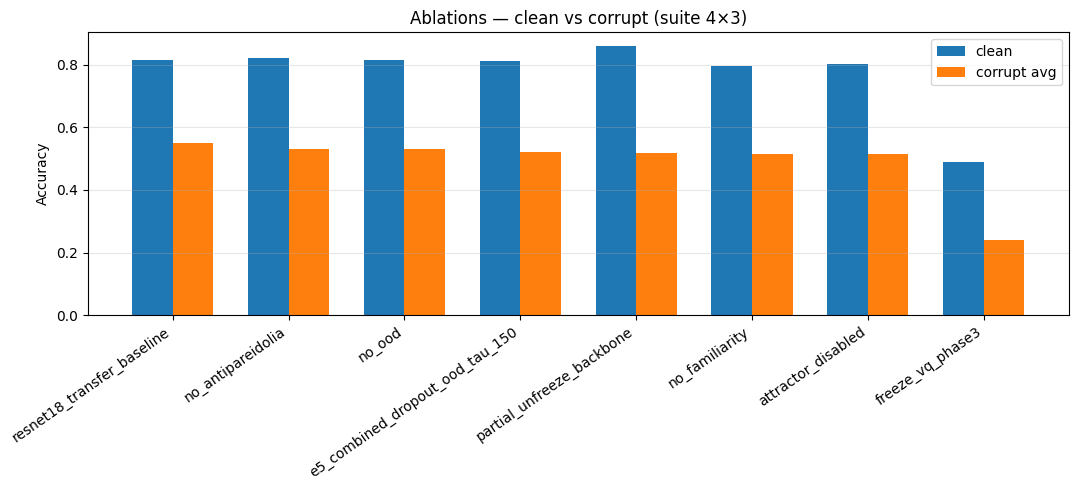

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ranked))
width = 0.35
ax.bar(x - width/2, ranked['clean_acc'], width, label='clean')
ax.bar(x + width/2, ranked['corrupt_acc_avg'], width, label='corrupt avg')
ax.set_xticks(x); ax.set_xticklabels(ranked['variant'], rotation=35, ha='right')
ax.set_ylabel('Accuracy'); ax.set_title('Ablations — clean vs corrupt (suite 4×3)')
ax.grid(alpha=0.3, axis='y'); ax.legend()
ensure_dir(OUT / 'plots')
fig.savefig(OUT / 'plots' / 'ablations_clean_vs_corrupt.png', dpi=120, bbox_inches='tight')
plt.tight_layout(); plt.show()